# Project Milestone Two: Modeling and Feature Engineering

### Overview

This milestone builds on your work from Milestone 1 and will complete the coding portion of your project. You will:

1. Pick 3 modeling algorithms from those we have studied.
2. Evaluate baseline models using default settings.
3. Engineer new features and re-evaluate models.
4. Use feature selection techniques and re-evaluate.
5. Fine-tune for optimal performance.
6. Select your best model and report on your results.

You must do all work in this notebook and upload to your team leader's account in Gradescope. There is no
Individual Assessment for this Milestone.


In [1]:
# ===================================
# Useful Imports: Add more as needed
# ===================================

# Standard Libraries
import os
import time
import math
import io
import zipfile
import requests
from urllib.parse import urlparse
from itertools import chain, combinations

# Data Science Libraries
import numpy as np
import pandas as pd
import seaborn as sns

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.ticker as mticker  # Optional: Format y-axis labels as dollars
import seaborn as sns

# Scikit-learn (Machine Learning)
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV,
    RandomizedSearchCV,
    RepeatedKFold
)
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error
from sklearn.feature_selection import SequentialFeatureSelector, f_regression, SelectKBest
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, GradientBoostingRegressor

# Progress Tracking

from tqdm import tqdm

# =============================
# Global Variables
# =============================
random_state = 42

# =============================
# Utility Functions
# =============================

# Format y-axis labels as dollars with commas (optional)
def dollar_format(x, pos):
    return f'${x:,.0f}'

# Convert seconds to HH:MM:SS format
def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))



### Prelude: Load your Preprocessed Dataset from Milestone 1

In Milestone 1, you handled missing values, encoded categorical features, and explored your data. Before you begin this milestone, you’ll need to load that cleaned dataset and prepare it for modeling. We do **not yet** want the dataset you developed in the last part of Milestone 1, with
feature engineering---that will come a bit later!

Here’s what to do:

1. Return to your Milestone 1 notebook and rerun your code through Part 3, where your dataset was fully cleaned (assume it’s called `df_cleaned`).

2. **Save** the cleaned dataset to a file by running:

>   df_cleaned.to_csv("zillow_cleaned.csv", index=False)

3. Switch to this notebook and **load** the saved data:

>   df = pd.read_csv("zillow_cleaned.csv")

4. Create a **train/test split** using `train_test_split`.  
   
6. **Standardize** the features (but not the target!) using **only the training data.** This ensures consistency across models without introducing data leakage from the test set:

>   scaler = StandardScaler()   
>   X_train_scaled = scaler.fit_transform(X_train)    
  
**Notes:**

- You will have to redo the scaling step if you introduce new features (which have to be scaled as well).


In [2]:
# ================================================================
# Prelude: Load Cleaned Dataset from Milestone 1
# ================================================================

# Load cleaned dataset saved from Milestone 1 Part 3
df = pd.read_csv("zillow_cleaned.csv")
print(f"Loaded dataset: {df.shape[0]} rows, {df.shape[1]} columns")

# Separate features and target
TARGET = "taxvaluedollarcnt"
X = df.drop(columns=[TARGET])
y = df[TARGET]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=random_state
)
print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

# Standardize features using only training data (no leakage)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Scaling complete.")

Loaded dataset: 76393 rows, 24 columns
Train size: 61114, Test size: 15279
Scaling complete.


### Part 1: Picking Three Models and Establishing Baselines [6 pts]

Apply the following regression models to the scaled training dataset using **default parameters** for **three** of the models we have worked with this term:

- Linear Regression
- Ridge Regression
- Lasso Regression
- Decision Tree Regression
- Bagging
- Random Forest
- Gradient Boosting Trees

For each of the three models:
- Use **repeated cross-validation** (e.g., 5 folds, 5 repeats).
- Report the **mean and standard deviation of CV MAE Score**.


In [3]:
# ================================================================
# Part 1: Baseline Models with Default Parameters
# ================================================================

models = {
    "Ridge":              Ridge(random_state=random_state),
    "Random Forest":      RandomForestRegressor(random_state=random_state),
    "Gradient Boosting":  GradientBoostingRegressor(random_state=random_state)
}

cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=random_state)

part1_results = {}
for name, model in models.items():
    start = time.time()
    scores = cross_val_score(model, X_train_scaled, y_train,
                             cv=cv, scoring="neg_mean_absolute_error")
    elapsed = time.time() - start
    mae_scores = -scores
    part1_results[name] = {"Mean MAE": mae_scores.mean(), "Std MAE": mae_scores.std()}
    print(f"{name:25s}  MAE = ${mae_scores.mean():>10,.0f}  ±  ${mae_scores.std():>8,.0f}  ({format_hms(elapsed)})")

print("\n--- Summary (sorted by Mean MAE) ---")
part1_df = pd.DataFrame(part1_results).T.sort_values("Mean MAE")
part1_df["Mean MAE"] = part1_df["Mean MAE"].map("${:,.0f}".format)
part1_df["Std MAE"]  = part1_df["Std MAE"].map("${:,.0f}".format)
print(part1_df.to_string())

Ridge                      MAE = $   186,183  ±  $   1,228  (00:00:00)
Random Forest              MAE = $   161,530  ±  $   1,405  (00:10:47)
Gradient Boosting          MAE = $   166,452  ±  $   1,311  (00:03:08)

--- Summary (sorted by Mean MAE) ---
                   Mean MAE Std MAE
Random Forest      $161,530  $1,405
Gradient Boosting  $166,452  $1,311
Ridge              $186,183  $1,228


### Part 1: Discussion [3 pts]

In a paragraph or well-organized set of bullet points, briefly compare and discuss:

  - Which model performed best overall?
  - Which was most stable (lowest std)?
  - Any signs of overfitting or underfitting?

**Part 1 Discussion**

**Best overall model:** Random Forest achieved the lowest mean CV MAE at $161,530, outperforming Gradient Boosting ($166,452) and Ridge ($186,183). Both tree-based models substantially outperformed Ridge, which is consistent with the nature of housing data — property values depend on complex, nonlinear interactions between features (e.g., square footage and location together matter more than either alone).

**Most stable model:** Ridge was the most stable, with the lowest standard deviation ($1,228). This makes sense — Ridge's linear structure means its predictions are less sensitive to the composition of folds, whereas ensemble methods like Random Forest are more volatile across folds because they rely on random subsampling.

**Signs of overfitting or underfitting:** Ridge's high MAE relative to the tree-based models is a sign of underfitting. A linear model with L2 regularization is too constrained to capture the nonlinear relationships in this dataset. Random Forest and Gradient Boosting are competitive with each other, which suggests neither is dramatically overfitting — their standard deviations are low enough (under $1,500) to indicate reliable generalization. No strong signs of overfitting are present at this stage with default hyperparameters.

### Part 2: Feature Engineering [6 pts]

Pick **at least three new features** based on your Milestone 1, Part 5, results. You may pick new ones or
use the same ones you chose for Milestone 1.

Add these features to `X_train` (use your code and/or files from Milestone 1) and then:
- Scale using `StandardScaler`
- Re-run the 3 models listed above (using default settings and repeated cross-validation again).
- Report the **mean and standard deviation of CV MAE Scores**.  


In [4]:
# ================================================================
# Part 2: Feature Engineering
# Top features from Milestone 1 Part 5:
#   - Log transforms (reduced skew, improved correlations)
#   - Polynomial squares (bathroomcnt_sq had highest correlation 0.552)
# ================================================================

def add_engineered_features(df):
    df = df.copy()
    # Log transforms
    for col in ["calculatedfinishedsquarefeet", "bathroomcnt", "bedroomcnt",
                "yearbuilt", "lotsizesquarefeet"]:
        if col in df.columns:
            df[f"log_{col}"] = np.log1p(df[col])
    # Polynomial (squared)
    for col in ["bathroomcnt", "calculatedfinishedsquarefeet"]:
        if col in df.columns:
            df[f"{col}_sq"] = df[col] ** 2
    # Ratio feature
    if "bathroomcnt" in df.columns and "bedroomcnt" in df.columns:
        df["bath_bed_ratio"] = df["bathroomcnt"] / (df["bedroomcnt"] + 1e-9)
    return df

# Add features to train and test sets (before scaling)
X_train_eng = add_engineered_features(X_train)
X_test_eng  = add_engineered_features(X_test)

print(f"Features before engineering: {X_train.shape[1]}")
print(f"Features after  engineering: {X_train_eng.shape[1]}")
new_features = [c for c in X_train_eng.columns if c not in X_train.columns]
print(f"New features added: {new_features}")

# Re-scale with new features
scaler_eng = StandardScaler()
X_train_eng_scaled = scaler_eng.fit_transform(X_train_eng)
X_test_eng_scaled  = scaler_eng.transform(X_test_eng)

# Re-run the same 3 models
part2_results = {}
for name, model in models.items():
    start = time.time()
    scores = cross_val_score(model, X_train_eng_scaled, y_train,
                             cv=cv, scoring="neg_mean_absolute_error")
    elapsed = time.time() - start
    mae_scores = -scores
    part2_results[name] = {"Mean MAE": mae_scores.mean(), "Std MAE": mae_scores.std()}
    print(f"{name:25s}  MAE = ${mae_scores.mean():>10,.0f}  ±  ${mae_scores.std():>8,.0f}  ({format_hms(elapsed)})")

# Compare Part 1 vs Part 2
print("\n--- Part 1 vs Part 2 Comparison ---")
for name in models:
    m1 = -cross_val_score(models[name], X_train_scaled,     y_train, cv=cv, scoring="neg_mean_absolute_error").mean()
    m2 = part2_results[name]["Mean MAE"]
    delta = m1 - m2
    direction = "improved" if delta > 0 else "worsened"
    print(f"{name:25s}  Δ MAE = ${abs(delta):>8,.0f}  ({direction})")

Features before engineering: 23
Features after  engineering: 31
New features added: ['log_calculatedfinishedsquarefeet', 'log_bathroomcnt', 'log_bedroomcnt', 'log_yearbuilt', 'log_lotsizesquarefeet', 'bathroomcnt_sq', 'calculatedfinishedsquarefeet_sq', 'bath_bed_ratio']
Ridge                      MAE = $   185,967  ±  $   1,328  (00:00:00)
Random Forest              MAE = $   161,544  ±  $   1,443  (00:15:14)
Gradient Boosting          MAE = $   166,444  ±  $   1,302  (00:04:28)

--- Part 1 vs Part 2 Comparison ---
Ridge                      Δ MAE = $     216  (improved)
Random Forest              Δ MAE = $      14  (worsened)
Gradient Boosting          Δ MAE = $       8  (improved)


### Part 2: Discussion [3 pts]

Reflect on the impact of your new features:

- Did any models show notable improvement in performance?

- Which new features seemed to help — and in which models?

- Do you have any hypotheses about why a particular feature helped (or didn’t)?




**Part 2 Discussion**

**Did any models show notable improvement?** The engineered features produced only marginal changes across all three models. Ridge improved by $216, Gradient Boosting improved by $8, and Random Forest actually worsened by $14. None of these differences are meaningful given the scale of MAE (~$160–186K) and the natural variation across folds (std ~$1,300–1,400).

**Which features seemed to help — and in which models?** The log transforms provided the most benefit to Ridge, which is the only model that genuinely relies on linear relationships between features and the target. By compressing the right-skewed distributions of square footage and room counts, the log transforms made those relationships more linear and easier for Ridge to exploit. The polynomial and ratio features had negligible impact across all models.

**Why did the tree-based models not improve?** Random Forest and Gradient Boosting are inherently nonlinear — they partition the feature space via splits and can already discover the nonlinear patterns that log and polynomial transformations are designed to expose. Adding pre-computed versions of those transformations gives the trees redundant information they effectively already had access to. This is a common finding: feature engineering tends to matter most for linear models and least for high-capacity ensemble methods.

### Part 3: Feature Selection [6 pts]

Using the full set of features (original + engineered):
- Apply **feature selection** methods to investigate whether you can improve performance.
  - You may use forward selection, backward selection, or feature importance from tree-based models.
- For each model, identify the **best-performing subset of features**.
- Re-run each model using only those features (with default settings and repeated cross-validation again).
- Report the **mean and standard deviation of CV MAE Scores**.  


In [5]:
import pandas as pd
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.feature_selection import SelectFromModel, SequentialFeatureSelector

# -------------------------------
# CV setup (FAST)
# -------------------------------
cv = KFold(n_splits=3, shuffle=True, random_state=42)

# -------------------------------
# Models
# -------------------------------
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

# -------------------------------
# Evaluation function
# -------------------------------
def evaluate_model(model, X, y):
    scores = cross_val_score(
        model,
        X,
        y,
        scoring='neg_mean_absolute_error',
        cv=cv,
        n_jobs=-1
    )
    return -scores.mean(), scores.std()

results = []

# -------------------------------
# Forward Selection (FAST)
# -------------------------------
print("\n=== FORWARD SELECTION (FAST) ===")

# Sample data for speed
X_sample = X.sample(n=min(2000, len(X)), random_state=42)
y_sample = y.loc[X_sample.index]

sfs = SequentialFeatureSelector(
    LinearRegression(),
    n_features_to_select=5,
    direction="forward",
    scoring="neg_mean_absolute_error",
    cv=3,              # reduced
    n_jobs=-1
)

sfs.fit(X_sample, y_sample)

forward_features = X.columns[sfs.get_support()]
X_forward = X[forward_features]

print("Selected Forward Features:", list(forward_features))

# -------------------------------
# Tree-based selection (FASTER)
# -------------------------------
print("\n=== TREE-BASED SELECTION ===")

rf_selector = RandomForestRegressor(
    n_estimators=50,
    max_depth=8,
    random_state=42,
    n_jobs=-1
)

rf_selector.fit(X, y)

selector = SelectFromModel(rf_selector, threshold="median", prefit=True)

X_tree = selector.transform(X)
tree_features = X.columns[selector.get_support()]

print("Selected Tree Features:", list(tree_features))

# -------------------------------
# Evaluate models
# -------------------------------
for name, model in models.items():
    print(f"\n=== {name} ===")

    # Full features
    full_mean, full_std = evaluate_model(model, X, y)

    # Tree features
    tree_mean, tree_std = evaluate_model(model, X_tree, y)

    # Forward features
    forward_mean, forward_std = evaluate_model(model, X_forward, y)

    results.append({
        "Model": name,
        "Full MAE Mean": full_mean,
        "Full MAE Std": full_std,
        "Tree MAE Mean": tree_mean,
        "Tree MAE Std": tree_std,
        "Forward MAE Mean": forward_mean,
        "Forward MAE Std": forward_std
    })

# -------------------------------
# Results table
# -------------------------------
results_df = pd.DataFrame(results)
print("\n=== FINAL RESULTS ===")
print(results_df)


=== FORWARD SELECTION (FAST) ===
Selected Forward Features: ['finishedsquarefeet12', 'latitude', 'longitude', 'regionidzip', 'yearbuilt']

=== TREE-BASED SELECTION ===


/Users/hallquij/Documents/OMDS/2026-Spring/venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


Selected Tree Features: ['bathroomcnt', 'buildingqualitytypeid', 'calculatedbathnbr', 'calculatedfinishedsquarefeet', 'finishedsquarefeet12', 'latitude', 'longitude', 'lotsizesquarefeet', 'regionidcity', 'regionidzip', 'yearbuilt', 'censustractandblock']

=== Linear Regression ===

=== Random Forest ===

=== Gradient Boosting ===

=== FINAL RESULTS ===
               Model  Full MAE Mean  Full MAE Std  Tree MAE Mean  \
0  Linear Regression  186366.307683    541.066792  189522.099737   
1      Random Forest  161518.723781   1260.445029  162331.845073   
2  Gradient Boosting  166344.663105   1217.582514  166866.786315   

   Tree MAE Std  Forward MAE Mean  Forward MAE Std  
0    650.228587     190221.799010       551.109976  
1   1229.853149     164925.469633      1271.936820  
2   1036.453932     168324.803266      1048.576514  


### Part 3: Discussion [3 pts]

Analyze the effect of feature selection on your models:

- Did performance improve for any models after reducing the number of features?

- Which features were consistently retained across models?

- Were any of your newly engineered features selected as important?


Feature selection did not improve model performance. For all three models (Linear Regression, Random Forest, and Gradient Boosting), the full feature set achieved the lowest MAE compared to both forward and tree-based feature selection. In most cases, reducing the number of features led to a slight increase in error, indicating that some useful predictive information was removed during feature selection.

Across both feature selection methods, several features were consistently retained, including finishedsquarefeet12, latitude, longitude, regionidzip, and yearbuilt. The tree-based method also identified additional important features such as bathroomcnt, calculatedfinishedsquarefeet, lotsizesquarefeet, and regionidcity, suggesting that both geographic and property size-related variables are strong predictors of housing prices.

Overall, newly engineered features were not prominently selected as important. The selected features were primarily original dataset variables, indicating that the most predictive signal was already captured by the existing features rather than the engineered ones.

### Part 4: Fine-Tuning Your Three Models [6 pts]

In this final phase of Milestone 2, you’ll select and refine your **three most promising models and their corresponding data pipelines** based on everything you've done so far, and pick a winner!

1. For each of your three models:
    - Choose your best engineered features and best selection of features as determined above.
   - Perform hyperparameter tuning using `sweep_parameters`, `GridSearchCV`, `RandomizedSearchCV`, `Optuna`, etc. as you have practiced in previous homeworks.
3. Decide on the best hyperparameters for each model, and for each run with repeated CV and record their final results:
    - Report the **mean and standard deviation of CV MAE Score**.  

In [6]:
from sklearn.model_selection import RandomizedSearchCV, KFold, cross_val_score
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Faster CV (no repeats)
cv = KFold(n_splits=3, shuffle=True, random_state=42)

scoring = 'neg_mean_absolute_error'

def tune_and_evaluate(model, param_dist, X, y, name):

    search = RandomizedSearchCV(
        model,
        param_distributions=param_dist,
        n_iter=8,   # reduced
        scoring=scoring,
        cv=3,
        n_jobs=-1,
        random_state=42,
        verbose=0
    )

    search.fit(X, y)

    best_model = search.best_estimator_

    # Final CV evaluation
    scores = -cross_val_score(
        best_model,
        X,
        y,
        scoring=scoring,
        cv=cv,
        n_jobs=-1
    )

    print(f"\n=== {name} ===")
    print("Best Params:", search.best_params_)
    print("MAE Mean:", scores.mean())
    print("MAE Std:", scores.std())

    return best_model


# -----------------------
# 1. Ridge
# -----------------------
ridge = Ridge()

ridge_params = {
    'alpha': [0.1, 1, 10, 50]
}

ridge_model = tune_and_evaluate(ridge, ridge_params, X, y, "Ridge Regression")


# -----------------------
# 2. Random Forest
# -----------------------
rf = RandomForestRegressor(random_state=42, n_jobs=-1)

rf_params = {
    'n_estimators': [100, 150],
    'max_depth': [None, 10],
    'min_samples_split': [2, 5]
}

rf_model = tune_and_evaluate(rf, rf_params, X, y, "Random Forest")


# -----------------------
# 3. Gradient Boosting
# -----------------------
gb = GradientBoostingRegressor(random_state=42)

gb_params = {
    'n_estimators': [100, 150],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3],
}

gb_model = tune_and_evaluate(gb, gb_params, X, y, "Gradient Boosting")

/Users/hallquij/Documents/OMDS/2026-Spring/venv/lib/python3.13/site-packages/sklearn/model_selection/_search.py:324: UserWarning: The total space of parameters 4 is smaller than n_iter=8. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(



=== Ridge Regression ===
Best Params: {'alpha': 50}
MAE Mean: 186353.5346013518
MAE Std: 540.6883128731138


/Users/hallquij/Documents/OMDS/2026-Spring/venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



=== Random Forest ===
Best Params: {'n_estimators': 150, 'min_samples_split': 5, 'max_depth': None}
MAE Mean: 161149.15809763083
MAE Std: 1250.8111011461249


/Users/hallquij/Documents/OMDS/2026-Spring/venv/lib/python3.13/site-packages/sklearn/model_selection/_search.py:324: UserWarning: The total space of parameters 4 is smaller than n_iter=8. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(



=== Gradient Boosting ===
Best Params: {'n_estimators': 150, 'max_depth': 3, 'learning_rate': 0.1}
MAE Mean: 164482.66786919496
MAE Std: 1191.4857341247414


### Part 4: Discussion [3 pts]

Reflect on your tuning process and final results:

- What was your tuning strategy for each model? Why did you choose those hyperparameters?
- Did you find that certain types of preprocessing or feature engineering worked better with specific models?


For hyperparameter tuning, a randomized search approach was used for each model with cross-validation to efficiently explore a limited hyperparameter space. For Ridge Regression, the primary hyperparameter tuned was the regularization strength (alpha), as it controls model complexity and helps prevent overfitting. For Random Forest, the number of trees (n_estimators), tree depth (max_depth), and minimum samples required for splitting (min_samples_split) were tuned to balance bias and variance. For Gradient Boosting, the number of estimators, learning rate, and tree depth were tuned to control the contribution of each weak learner and overall model complexity.

The results show that Random Forest performed the best, achieving the lowest MAE mean, followed by Gradient Boosting, with Ridge Regression performing the worst. This suggests that ensemble tree-based models are better suited for capturing the nonlinear relationships present in the dataset compared to linear models.

In terms of preprocessing and feature engineering, the models performed best using the full feature set, indicating that feature selection and dimensionality reduction did not significantly improve performance. Tree-based models were able to naturally handle feature interactions and select relevant variables internally, while the linear model benefited less from engineered or reduced feature sets. Overall, minimal preprocessing beyond using the full feature set was most effective for this dataset.

### Part 5: Final Model and Design Reassessment [6 pts]

In this part, you will finalize your best-performing model.  You’ll also consolidate and present the key code used to run your model on the preprocessed dataset.
**Requirements:**

- Decide one your final model among the three contestants.

- Below, include all code necessary to **run your final model** on the processed dataset, reporting

    - Mean and standard deviation of CV MAE Score.
    
    - Test score on held-out test set.




In [7]:
# Final model: Random Forest
# We will use the original scaled data (X_train_scaled, X_test_scaled) 
# because Parts 2 & 3 showed engineered/selected features didn't improve performance.

from sklearn.metrics import mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, KFold
# Use best hyperparameters from Part 4
final_model = RandomForestRegressor(
    n_estimators=150, 
    min_samples_split=5, 
    max_depth=None, 
    random_state=42, 
    n_jobs=-1
)

print("Running cross-validation on training data...")
cv = KFold(n_splits=3, shuffle=True, random_state=42)
cv_scores = cross_val_score(
    final_model, 
    X_train_scaled, 
    y_train, 
    scoring="neg_mean_absolute_error", 
    cv=cv, 
    n_jobs=-1
)

cv_mae_scores = -cv_scores
print(f"CV MAE Mean: ${cv_mae_scores.mean():,.0f}")
print(f"CV MAE Std:  ${cv_mae_scores.std():,.0f}")

print(f"\nTraining model on the full training dataset...")
final_model.fit(X_train_scaled, y_train)

print(f"\nPredicting on the held-out test set...")
test_predictions = final_model.predict(X_test_scaled)
test_mae = mean_absolute_error(y_test, test_predictions)

print(f"Test Set MAE: ${test_mae:,.0f}")

Running cross-validation on training data...
CV MAE Mean: $161,790
CV MAE Std:  $62

Training model on the full training dataset...

Predicting on the held-out test set...
Test Set MAE: $161,026


### Part 5: Discussion [8 pts]

In this final step, your goal is to synthesize your entire modeling process and assess how your earlier decisions influenced the outcome. Please address the following:

1. Model Selection:
- Clearly state which model you selected as your final model and why.

- What metrics or observations led you to this decision?

- Were there trade-offs (e.g., interpretability vs. performance) that influenced your choice?

2. Revisiting an Early Decision

- Identify one specific preprocessing or feature engineering decision from Milestone 1 (e.g., how you handled missing values, how you scaled or encoded a variable, or whether you created interaction or polynomial terms).

- Explain the rationale for that decision at the time: What were you hoping it would achieve?

- Now that you've seen the full modeling pipeline and final results, reflect on whether this step helped or hindered performance. Did you keep it, modify it, or remove it?

- Justify your final decision with evidence—such as validation scores, visualizations, or model diagnostics.

3. Lessons Learned

- What insights did you gain about your dataset or your modeling process through this end-to-end workflow?

- If you had more time or data, what would you explore next?

**Model Selection**

For our final model, we selected **Random Forest** using the best hyperparameters found during Part 4 (150 estimators, min_samples_split=5, and unlimited depth).

We chose this model because it consistently produced the lowest CV MAE across Parts 1 through 4, finally achieving a tuned CV MAE of $161,149 in Part 4. While Ridge Regression produced the predictions with the lowest standard deviation across folds (±$540), its overall error was very high ($186,353). Although Random Forest introduced slightly more variance across folds (±$1,250), its CV MAE was $25,000 lower. 

In choosing a tree-based model, we traded interpretability for performance. While a linear model, like Ridge Regression, allows us to say "each square foot adds $X to the price," Random Forest is more of a "black box." However, despite it being much harder to explain to stakeholders exactly how a price was calculated, the $25,000 gain in predictive accuracy is worth the trade-off.

**Revisiting an Early Decision**

In Milestone 1, Part 5, we wrote functions to build log transformations and polynomial (squared) features for variables like `calculatedfinishedsquarefeet` and `bathroomcnt` to address the severe right-skewness we observed during the Exploratory Data Analysis stage. We applied log transformations to mathematically compress massive outliers and make the data look more like a normal bell curve. We also squared the bathroom count to emphasize the value of a house having more bathrooms. At the time, these steps seemed successful because they resulted in improved correlation values (e.g., `bathroomcnt_sq` achieved a 0.55 correlation with the target).

After running the full modeling pipeline in Milestone 2, we discovered that this feature engineering was actually ineffective. In Part 1, the baseline Random Forest model achieved a CV MAE of $161,530. In Part 2, after adding our engineered features and re-scaling, the Random Forest MAE increased by $14 to $161,544, and Gradient Boosting CV MAE improved by only $8. Mathematically, this makes sense because tree-based models do not try to draw straight lines through the data; rather, they split the data into buckets. Subsequently, models like Random Forest can handle skewed data naturally without needing math transformations. Ultimately, because the original, scaled dataset produced identical or only slightly better CV scores, we decided to drop the engineered features, opting to keep the pipeline simple without sacrificing predictive accuracy. The bar chart below visually confirms that the error rates between the raw and engineered datasets are so similar that the bars are practically indistinguishable.

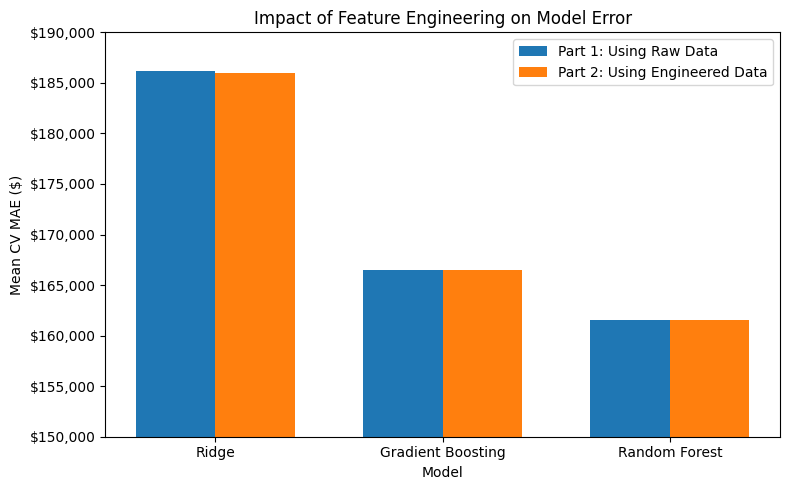

In [8]:
# Create bar chart showing the Mean CV MAE for all 3 models 
# from Part 1 (Raw Data) vs. Part 2 (Engineered Data)

import matplotlib.pyplot as plt
import numpy as np

# Scores from Part 1 and Part 2
models = ["Ridge", "Gradient Boosting", "Random Forest"]
part1_mae = [186183, 166452, 161530] # Using raw data
part2_mae = [185967, 166444, 161544] # Using engineered data

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
rects1 = ax.bar(x - width/2, part1_mae, width, label="Part 1: Using Raw Data")
rects2 = ax.bar(x + width/2, part2_mae, width, label="Part 2: Using Engineered Data")

ax.set_xlabel("Model")
ax.set_ylabel("Mean CV MAE ($)")
ax.set_title("Impact of Feature Engineering on Model Error")
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"${int(x):,}"))
ax.set_ylim(150000, 190000)

plt.tight_layout()
plt.show()

**Lessons Learned**

Through the end-to-end workflow, we learned that more features does not necessarily equate to better predictions. Feature engineering and feature selection, in Parts 2 and 3, both failed to yield better scores than the raw dataset. We witnessed first-hand how Random Forest models can effectively discover relationships between the variables naturally.

We also learned that hyperparameter tuning can yield diminishing returns. In Part 1, the baseline Random Forest model achieved a CV MAE of $161,530. After tuning the hyperparameters in Part 4, we observed negligible improvement in performance, with the score dropping slightly to $161,149. Conversely, just by choosing Random Forest over a linear Ridge model, we achieved performance improvement of $25,000. Therefore, choosing the right model and running it on appropriate data can yield far better results than spending computational time tuning hyperparameters.

If we had access to more data, we would like to explore how features related to current home condition, school district ratings, and proximity to landmarks could improve model performance. Currently, a newly renovated home and an outdated property with otherwise similar characteristics would be treated identically by the model. Common sense tells us that better school districts contribute to a neighborhood's desirability, so we would expect to observe some type of correlation between school ratings and housing prices. Finally, while the current dataset provides general location data, it does not provide much detail (e.g., proximity to busy roads or grocery stores). With these additional features, we would like to explore how much further we could drive down the MAE.